In [12]:
os.getcwd()

'c:\\Users\\dieyo\\OneDrive - 고려대학교\\2_My-Programming\\0_DL_from_scratch\\experiment\\4_simple_CNN'

In [13]:
# coding: utf-8
import sys, os
sys.path.append('../../official_github')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append('../')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append('./official_github/')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from simple_convnet import SimpleConvNet
from common.trainer import Trainer




In [14]:
test_dict = {}
train_dict = {}
root_path = '../datasets/cifar-10-batches-py/'


def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

accepted_keys = [b'labels', b'data'] ## select keys from [b'batch_label', b'labels', b'data', b'filenames']
for dir in os.listdir(root_path):
    if dir == 'batches.meta':
        pass
    elif dir == 'test_batch':
        test_batch = unpickle(os.path.join(root_path, dir))
        test_dict.update((k,np.array(v)) for k,v in test_batch.items() if k in accepted_keys)
    else:
        train_batch = unpickle(os.path.join(root_path, dir))
        if not train_dict:
            train_dict.update((k,np.array(v)) for k,v in train_batch.items() if k in accepted_keys)
        else:
            for key in accepted_keys:
                train_dict[key] = np.concatenate((train_dict[key], train_batch[key]), axis=0)


## CIFAR data's shape are (N, H*W*C). 
## If you want to convert them into numpy-standard (N, H, W, C) or pytorch-standard (N, C, H ,W) shape, run following codes.
def numpy2rgb(arr: np.ndarray, way='torch') -> np.ndarray:
    batch_size = len(arr)
    if way == 'numpy':
        arr = arr.reshape(batch_size, 3, 32, 32).transpose(0,2,3,1)
    elif way == 'torch':
        arr = arr.reshape(batch_size, 3, 32, 32).transpose(0,1,2,3)
        
    
    return arr


train_dict[b'data'] = numpy2rgb(train_dict[b'data'])
test_dict[b'data'] = numpy2rgb(test_dict[b'data'])

In [15]:
# @jit
def normalize(data: np.ndarray, mean: int=None, std: int=None) -> np.ndarray:
    if mean == None:
        mean = np.mean(data)
        
    if std == None:
        std = np.std(data)
    
    data = (data - mean) / std
    return data

In [16]:
x_train, t_train = normalize(train_dict[b'data']), train_dict[b'labels']
x_test, t_test = normalize(test_dict[b'data']), test_dict[b'labels']

print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

(50000, 3, 32, 32)
2.09341038199596
(50000,)


In [17]:
max_epochs = 10

network = SimpleConvNet(input_dim=(3,32,32), 
                        conv_param = {'filter_num': 30, 'filter_size': 5, 'pad': 0, 'stride': 1},
                        hidden_size=100, output_size=10, weight_init_std=0.01)
                        
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=max_epochs, mini_batch_size=100,
                  optimizer='SGD', optimizer_param={'lr': 0.001},
                  evaluate_sample_num_per_epoch=1000)
trainer.train()

# 매개변수 보존
network.save_params("params.pkl")
print("Saved Network Parameters!")

train loss:2.3026543612482606
=== epoch:1, train acc:0.099, test acc:0.101 ===
train loss:2.302097259688885
train loss:2.302558565969444
train loss:2.3024254062963485
train loss:2.3023584571219513
train loss:2.3022324645924486
train loss:2.3022785697805777
train loss:2.302133166135356
train loss:2.3019025225830068
train loss:2.3022609351042225
train loss:2.3027265003757726
train loss:2.3013790191070034
train loss:2.3029067941163737
train loss:2.3026722289288286
train loss:2.3023091831652844
train loss:2.3026720618758283
train loss:2.3017372700066105
train loss:2.3024241946988933
train loss:2.302320814129267
train loss:2.301508854119469
train loss:2.3019447113151448
train loss:2.30270851156783
train loss:2.3023587867280986
train loss:2.302180851656008
train loss:2.3023066247300643
train loss:2.302771069340328
train loss:2.302454741440169
train loss:2.3025751825146243
train loss:2.302584603811986
train loss:2.3028041042494296
train loss:2.3026894765206563
train loss:2.302166226774359
tra

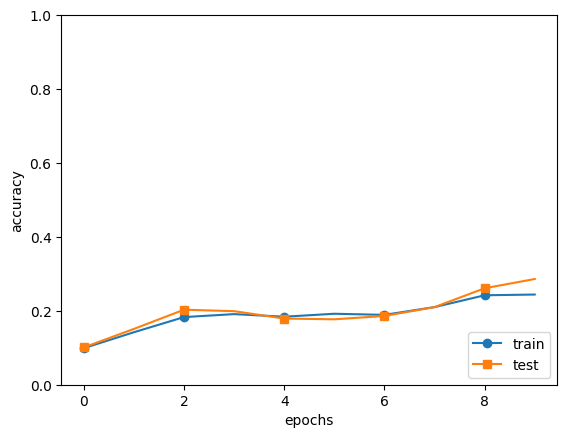

In [18]:

# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, trainer.train_acc_list, marker='o', label='train', markevery=2)
plt.plot(x, trainer.test_acc_list, marker='s', label='test', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()